In [1]:
from pathlib import Path

import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from tqdm.auto import tqdm

from configuration import (
    SAMPLE_RATE, HOP_LENGTH, BATCH_SIZE, AE_EPOCHS, LR,
    KL_WEIGHT, KL_ANNEAL_EPOCHS,
    DATA_GLOB, OUTPUT_DIR, VAE_CKPT_PATH, LATENT_CHANNELS, MEL_TIME_DIVISOR,
    device,
)
from dataset import MelDataset, trim_to_shape
from models import VAE

print('device:', device)

/home/matej/Documents/DIPLRAD/music_gen_v2/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


In [2]:
from dataset.create_chunks import iter_chunks
# audio_files = sorted(Path().glob(DATA_GLOB))
audio_files = iter_chunks("../musdb18/musdb18_mixtures", "train", 10, 15)
# print('found files:', len(audio_files))
# if len(audio_files) == 0:
#    raise FileNotFoundError(f'No WAV files found matching: {DATA_GLOB}')

In [3]:
dataset = MelDataset(audio_files)
n_val   = max(1, int(0.2 * len(dataset))) if len(dataset) > 1 else 0
n_train = len(dataset) - n_val

if n_val > 0:
    train_ds, val_ds = random_split(dataset, [n_train, n_val])
else:
    train_ds = val_ds = dataset

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

sample = next(iter(train_loader))
print('sample shape:', sample.shape)

sample shape: torch.Size([8, 1, 80, 216])


In [4]:
def kl_divergence(mu, logvar):
    return -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())


def kl_annealed_weight(epoch: int, total_anneal_epochs: int = KL_ANNEAL_EPOCHS,
                       max_weight: float = KL_WEIGHT) -> float:

    if total_anneal_epochs <= 0:
        return max_weight
    return min(max_weight, max_weight * (epoch + 1) / total_anneal_epochs)


def evaluate_vae(model, loader):
    model.eval()
    recon_losses, kl_losses = [], []
    with torch.no_grad():
        for x in loader:
            x = x.to(device)
            x_hat, mu, logvar = model(x)
            x_hat = trim_to_shape(x_hat, x.shape[-2:])
            recon_losses.append(F.l1_loss(x_hat, x).item())
            kl_losses.append(kl_divergence(mu, logvar).item())
    return np.mean(recon_losses), np.mean(kl_losses)

In [5]:
def maybe_load_vae(model, path=VAE_CKPT_PATH, map_location=device):
    path = Path(path)
    if path.exists():
        ckpt = torch.load(path, map_location=map_location)
        model.load_state_dict(ckpt['model_state'])
        print(f'Loaded VAE checkpoint from {path}')
        return ckpt
    print(f'No VAE checkpoint found at {path}, training from scratch.')
    return None


def save_vae_checkpoint(model, history=None, path=VAE_CKPT_PATH):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({
        'model_state':      model.state_dict(),
        'history':          history,
        'latent_channels':  LATENT_CHANNELS,
        'mel_time_divisor': MEL_TIME_DIVISOR,
    }, path)
    print(f'Saved VAE checkpoint to {path}')

In [6]:
def train_vae(model, train_loader, val_loader, epochs=AE_EPOCHS, lr=LR):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    for epoch in range(epochs):
        kl_w = kl_annealed_weight(epoch)

        model.train()
        train_losses = []
        for x in tqdm(train_loader, leave=False):
            x = x.to(device)
            x_hat, mu, logvar = model(x)
            x_hat = trim_to_shape(x_hat, x.shape[-2:])
            recon = F.l1_loss(x_hat, x)
            kl    = kl_divergence(mu, logvar)
            loss  = recon + kl_w * kl
            opt.zero_grad()
            loss.backward()
            opt.step()
            train_losses.append([loss.item(), recon.item(), kl.item()])

        val_recon, val_kl = evaluate_vae(model, val_loader)
        train_mean = np.mean(train_losses, axis=0)
        history.append({
            'epoch':       epoch + 1,
            'kl_weight':   kl_w,
            'train_loss':  float(train_mean[0]),
            'train_recon': float(train_mean[1]),
            'train_kl':    float(train_mean[2]),
            'val_recon':   float(val_recon),
            'val_kl':      float(val_kl),
        })
        print(
            f"epoch {epoch+1}/{epochs} | kl_w {kl_w:.1e} | "
            f"train loss {train_mean[0]:.4f} | train recon {train_mean[1]:.4f} | "
            f"train kl {train_mean[2]:.4f} | val recon {val_recon:.4f} | val kl {val_kl:.4f}"
        )
    return history


vae     = VAE().to(device)
vae_ckpt = maybe_load_vae(vae)
if vae_ckpt is None:
    vae_history = train_vae(vae, train_loader, val_loader)
    save_vae_checkpoint(vae, vae_history)
else:
    vae_history = vae_ckpt.get('history', [])

No VAE checkpoint found at ../musdb18/output/vae_checkpoint.pt, training from scratch.


epoch 1/30 | kl_w 1.0e-04 | train loss 0.1203 | train recon 0.1202 | train kl 1.1197 | val recon 0.1226 | val kl 4.5668


epoch 2/30 | kl_w 2.0e-04 | train loss 0.0917 | train recon 0.0912 | train kl 2.2918 | val recon 0.1061 | val kl 1.5955


epoch 3/30 | kl_w 3.0e-04 | train loss 0.0803 | train recon 0.0797 | train kl 1.8716 | val recon 0.0888 | val kl 2.1456


epoch 4/30 | kl_w 4.0e-04 | train loss 0.0764 | train recon 0.0757 | train kl 1.7543 | val recon 0.0842 | val kl 1.9886


...

epoch 26/30 | kl_w 1.0e-03 | train loss 0.0440 | train recon 0.0421 | train kl 1.8943 | val recon 0.0464 | val kl 1.8792


epoch 27/30 | kl_w 1.0e-03 | train loss 0.0437 | train recon 0.0418 | train kl 1.8952 | val recon 0.0457 | val kl 1.9825


epoch 28/30 | kl_w 1.0e-03 | train loss 0.0427 | train recon 0.0408 | train kl 1.9323 | val recon 0.0453 | val kl 1.9780


epoch 29/30 | kl_w 1.0e-03 | train loss 0.0423 | train recon 0.0403 | train kl 1.9411 | val recon 0.0448 | val kl 1.9395


epoch 30/30 | kl_w 1.0e-03 | train loss 0.0422 | train recon 0.0402 | train kl 1.9568 | val recon 0.0446 | val kl 1.9493
Saved VAE checkpoint to ../musdb18/output/vae_checkpoint.pt


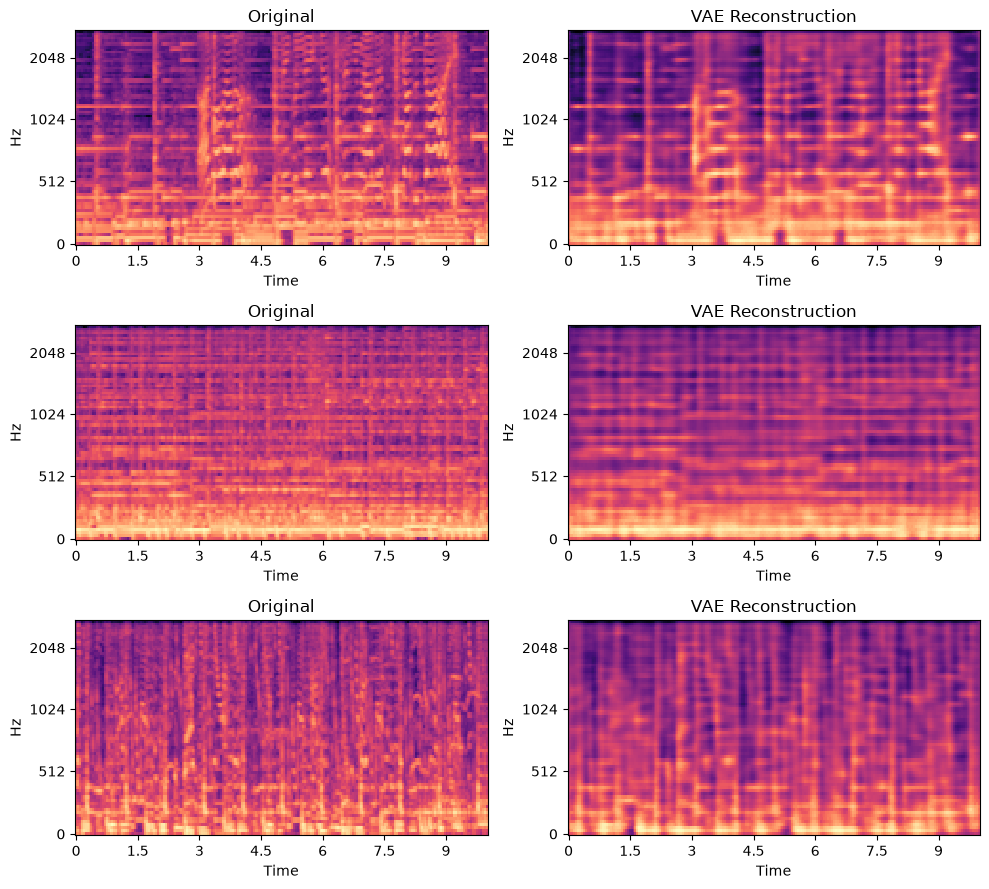

In [8]:
vae.eval()
x = next(iter(val_loader)).to(device)
with torch.no_grad():
    x_hat, mu, logvar = vae(x)

n_show = min(3, x.size(0))
fig, axes = plt.subplots(n_show, 2, figsize=(10, 3 * n_show))
if n_show == 1:
    axes = np.array([axes])

for i in range(n_show):
    orig = x[i, 0].detach().cpu().numpy() * 80.0 - 80.0
    rec  = x_hat[i, 0].detach().cpu().numpy() * 80.0 - 80.0
    librosa.display.specshow(orig, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                             x_axis='time', y_axis='mel', ax=axes[i, 0])
    axes[i, 0].set_title('Original')
    librosa.display.specshow(rec,  sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                             x_axis='time', y_axis='mel', ax=axes[i, 1])
    axes[i, 1].set_title('VAE Reconstruction')
plt.tight_layout()
plt.show()